# Hom-PGD: Star-Set Trajectory in Original and Latent Space

This tutorial runs Hom-PGD on a two-dimensional nonconvex star-shaped feasible set. The same saved run record drives the original-space trajectory, latent-space trajectory, and convergence curves.

**Learning goals.** You will: 

1. construct a star-constrained problem through the shared benchmark API;
2. obtain a multi-start IPOPT reference solution;
3. follow one Hom-PGD trajectory in both spaces; and
4. inspect objective and feasibility curves from the recorded iterates.

## 1. Explicit configuration

The star set is nonconvex, so this tutorial explicitly requests IPOPT. IPOPT is run from several polar starts and serves as a numerical reference, not a global-optimality proof for every nonconvex instance.

In [1]:
from __future__ import annotations

from pathlib import Path

WORKING_DIR = Path.cwd().resolve()
REPO_ROOT = WORKING_DIR if (WORKING_DIR / 'src' / 'homopt').is_dir() else WORKING_DIR.parents[1]
if not (REPO_ROOT / 'src' / 'homopt').is_dir():
    raise RuntimeError('Launch from the repository root or execute this notebook from tutorials/hom_pgd.')

TUTORIAL_CONFIG = {
    'seed': 2031,
    'device': 'cpu',
    'dtype': 'float32',
    'problem_type': 'star',
    'alpha': 0.35,
    'num_star': 5,
    'algorithms': ['Hom-PGD'],
    'max_iterations': 180,
    'max_running_time': 30.0,
    'learning_rate': 3e-2,
    'stepsize_rule': 'adaptive',
    'lr_decay': 0.995,
    'min_lr': 1e-6,
    'common_config': {
        'initial_point_mode': 'gauge_center',
        'convergence_threshold': 1e-8,
    },
    'algorithm_config': {
        'Hom-PGD': {'hom_p_norm': 2, 'learning_rate': 3e-2, 'momentum': 0.0},
    },
    'reference_solver': 'ipopt',
    'reference_label': 'IPOPT',
    'reference_ipopt_num_starts': 8,
    'x_grid_bounds': (-1.55, 1.55),
    'x_grid_size': 360,
    'z_grid_size': 220,
    'run_dir': REPO_ROOT / 'results' / 'tutorials' / 'hom_pgd' / '02_star_hom_pgd_trajectory',
    'figure_dir': REPO_ROOT / 'results' / 'figs' / 'tutorials' / 'hom_pgd' / '02_star_hom_pgd_trajectory',
}
# Keep each displayed panel at the same physical size in Jupyter and PDF output.
TUTORIAL_FIGURE_STYLE = {
    'panel_width': 5.6,
    'panel_height': 5.0,
    'single_panel': (5.6, 5.0),
    'two_panel': (11.2, 5.0),
}
TUTORIAL_CONFIG


{'seed': 2031,
 'device': 'cpu',
 'dtype': 'float32',
 'problem_type': 'star',
 'alpha': 0.35,
 'num_star': 5,
 'algorithms': ['Hom-PGD'],
 'max_iterations': 180,
 'max_running_time': 30.0,
 'learning_rate': 0.03,
 'stepsize_rule': 'adaptive',
 'lr_decay': 0.995,
 'min_lr': 1e-06,
 'common_config': {'initial_point_mode': 'gauge_center',
  'convergence_threshold': 1e-08},
 'algorithm_config': {'Hom-PGD': {'hom_p_norm': 2,
   'learning_rate': 0.03,
   'momentum': 0.0}},
 'reference_solver': 'ipopt',
 'reference_label': 'IPOPT',
 'reference_ipopt_num_starts': 8,
 'x_grid_bounds': (-1.55, 1.55),
 'x_grid_size': 360,
 'z_grid_size': 220,
 'run_dir': PosixPath('/Users/lem/Projects/HomOPT/results/tutorials/hom_pgd/02_star_hom_pgd_trajectory'),
 'figure_dir': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory')}

## 2. Run the shared benchmark once

`return_context=True` exposes the exact in-memory problem, map, reference, and records used by the run. The notebook does not recreate the parametric instance or rerun a solver for plotting.

In [2]:
import numpy as np

from homopt.experiments.hom_pgd import poly_star_benchmark
from homopt.viz import apply_paper_style_rcparams, build_convex_2d_traces

apply_paper_style_rcparams()
payload, run_context = poly_star_benchmark(
    algorithms=TUTORIAL_CONFIG['algorithms'],
    common_config=TUTORIAL_CONFIG['common_config'],
    algorithm_config=TUTORIAL_CONFIG['algorithm_config'],
    alpha=TUTORIAL_CONFIG['alpha'],
    num_star=TUTORIAL_CONFIG['num_star'],
    problem_type=TUTORIAL_CONFIG['problem_type'],
    max_iterations=TUTORIAL_CONFIG['max_iterations'],
    max_running_time=TUTORIAL_CONFIG['max_running_time'],
    learning_rate=TUTORIAL_CONFIG['learning_rate'],
    stepsize_rule=TUTORIAL_CONFIG['stepsize_rule'],
    lr_decay=TUTORIAL_CONFIG['lr_decay'],
    min_lr=TUTORIAL_CONFIG['min_lr'],
    seed=TUTORIAL_CONFIG['seed'],
    output_dir=TUTORIAL_CONFIG['run_dir'],
    device=TUTORIAL_CONFIG['device'],
    dtype=TUTORIAL_CONFIG['dtype'],
    visualize=False,
    reference_solver=TUTORIAL_CONFIG['reference_solver'],
    reference_label=TUTORIAL_CONFIG['reference_label'],
    reference_ipopt_num_starts=TUTORIAL_CONFIG['reference_ipopt_num_starts'],
    return_context=True,
)
problem = run_context['problem']
hom_map = run_context['hom_map']
reference = run_context['reference']
records = run_context['records']
traces = build_convex_2d_traces(problem, records, TUTORIAL_CONFIG['algorithms'])

{
    'reference_objective': float(reference['objective']),
    'reference_status': reference['status'],
    'run_objective': float(payload['objective']),
    'final_violation': float(run_context['summaries']['Hom-PGD']['final_violation']),
    'recorded_iterates': int(traces['Hom-PGD']['objective'].size),
}


Running Hom-PGD


{'reference_objective': 0.11649224907443691,
 'reference_status': 'optimal',
 'run_objective': 0.14482757449150085,
 'final_violation': 0.0,
 'recorded_iterates': 150}

## 3. One recorded trajectory in two spaces

The latent trajectory stays in the unit ball. Its gauge-map image follows the original-space trajectory on the left. The blue circle is the shared initial point and the red star is the last recorded iterate; the black star is the IPOPT reference.

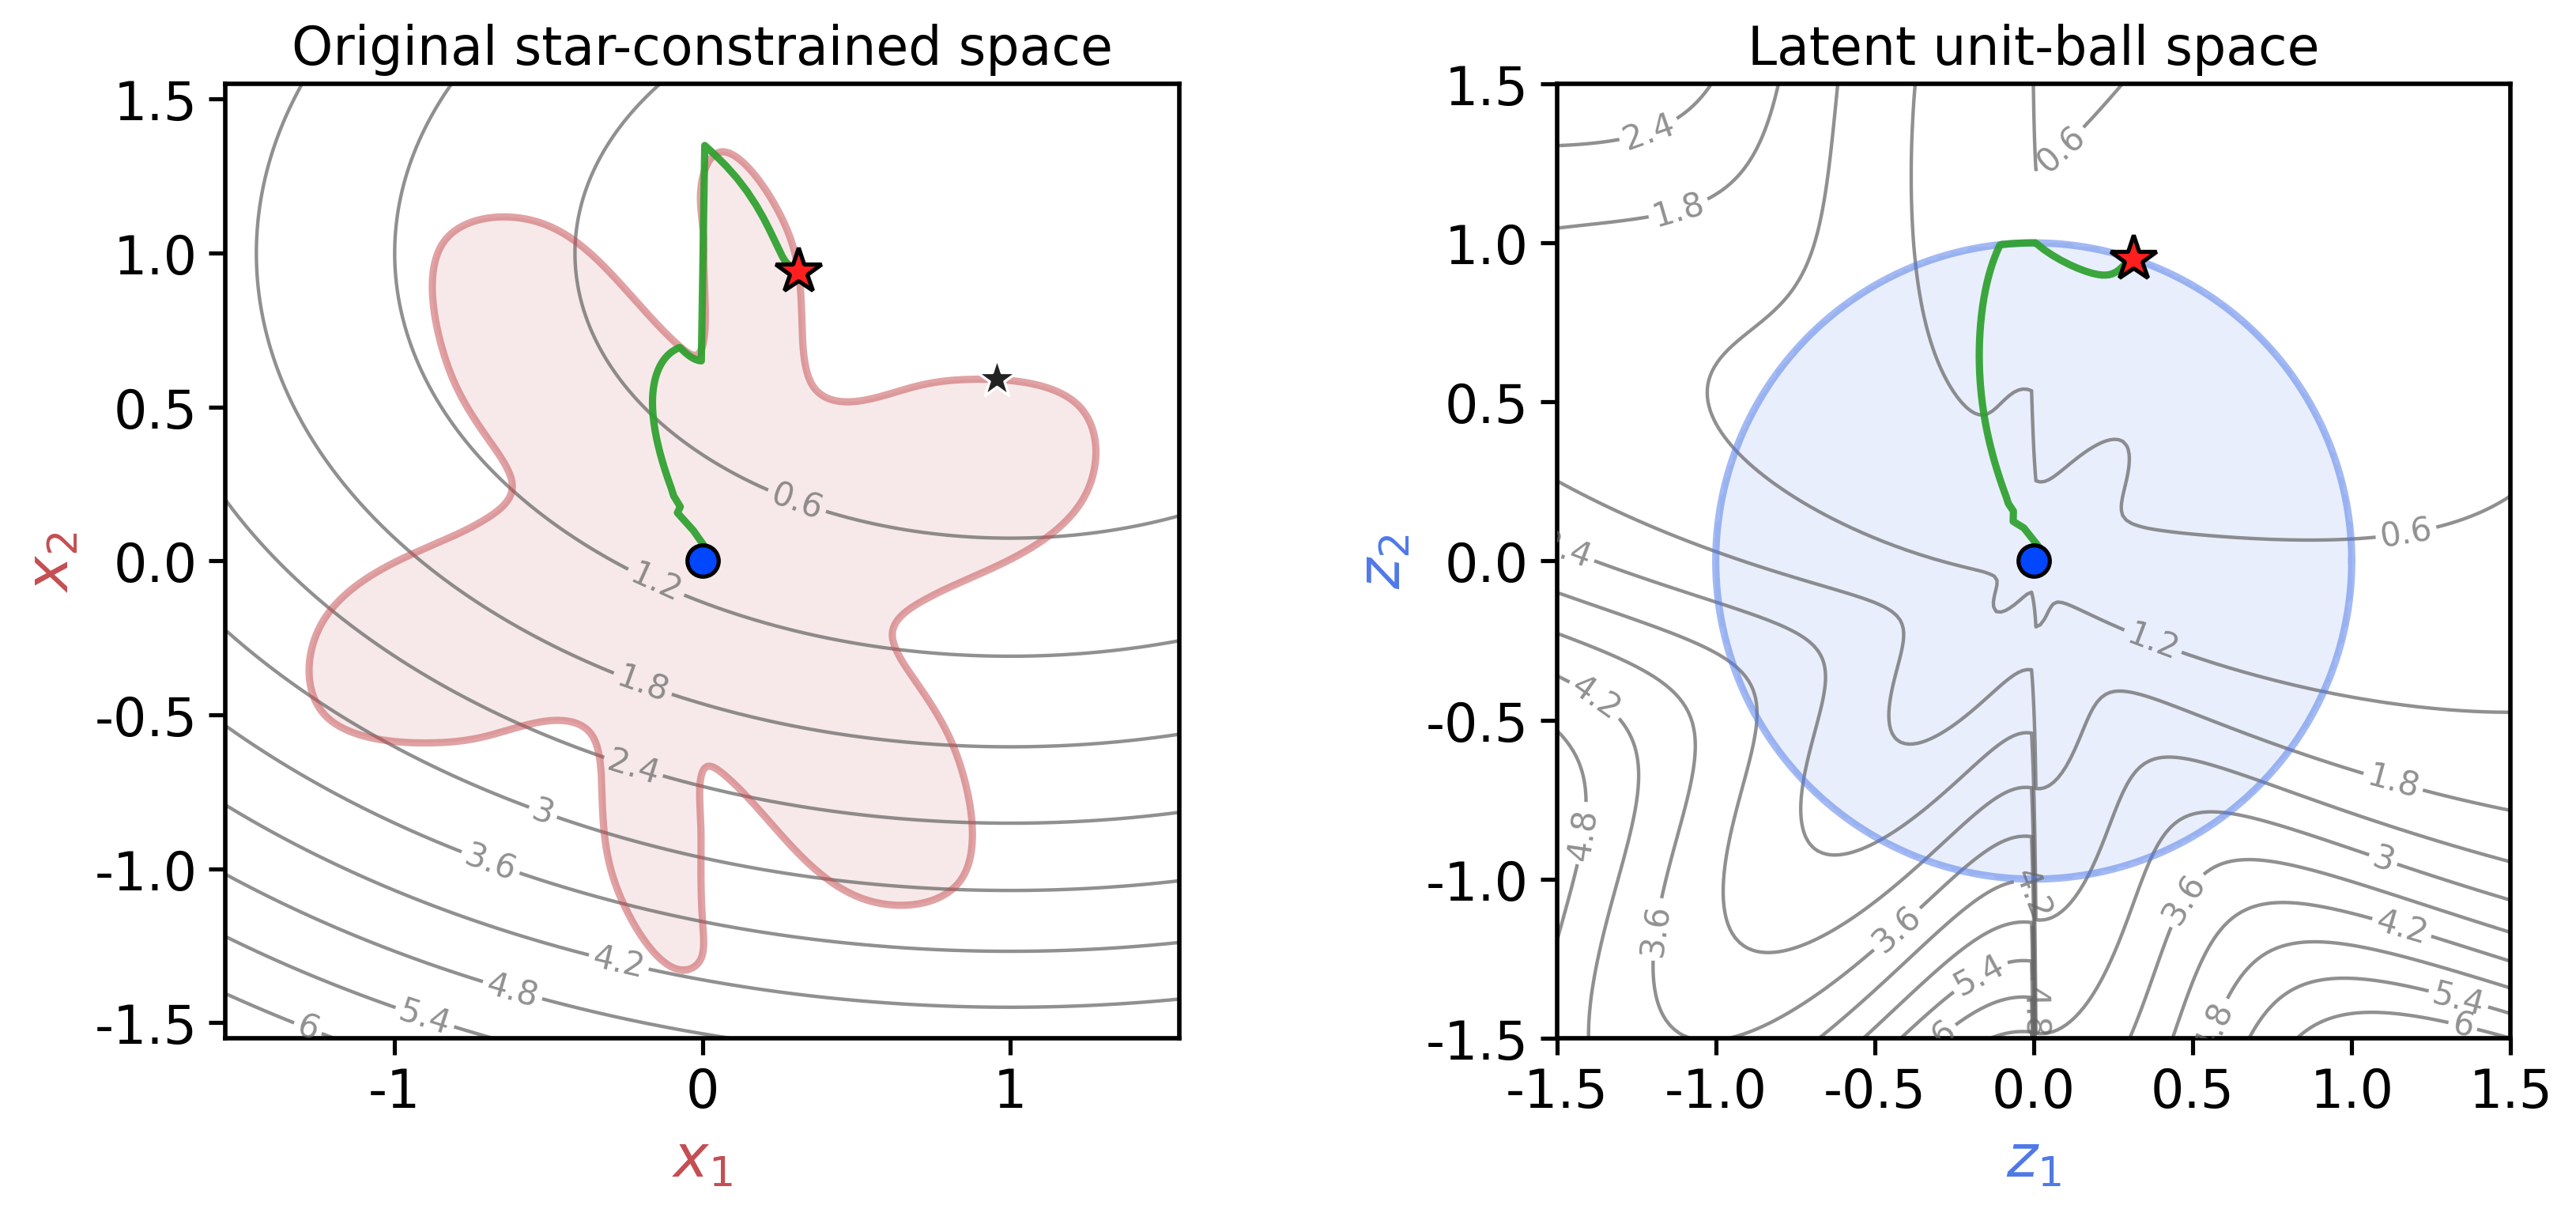

PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/original_and_latent_trajectory.pdf')

In [3]:
import matplotlib.pyplot as plt

from homopt.viz.artifacts import save_figure
from homopt.viz.landscapes import convex_landscape_grid, convex_z_landscape_grid
from homopt.viz.primitives import draw_convex_landscape, draw_convex_z_landscape, draw_trajectory

low = np.full(2, TUTORIAL_CONFIG['x_grid_bounds'][0], dtype=float)
high = np.full(2, TUTORIAL_CONFIG['x_grid_bounds'][1], dtype=float)
X, Y, objective, inequality, equality, eq_resid = convex_landscape_grid(
    problem, low, high, grid_size=TUTORIAL_CONFIG['x_grid_size']
)
Z1, Z2, z_objective, z_eq_resid, inside, p_norm = convex_z_landscape_grid(
    problem, hom_map, grid_size=TUTORIAL_CONFIG['z_grid_size']
)
trace = traces['Hom-PGD']
x_reference = np.asarray(reference['solution'], dtype=float).reshape(2)

fig, (ax_x, ax_z) = plt.subplots(1, 2, figsize=TUTORIAL_FIGURE_STYLE['two_panel'], constrained_layout=True)
draw_convex_landscape(ax_x, X, Y, objective, inequality, equality, eq_resid)
draw_trajectory(ax_x, trace['trajectory'], label=None)
ax_x.scatter(*x_reference, s=155, marker='*', color='#222222', edgecolor='white', linewidth=0.8, zorder=8)
ax_x.set_title('Original star-constrained space')

draw_convex_z_landscape(ax_z, Z1, Z2, z_objective, z_eq_resid, inside, p_norm)
draw_trajectory(ax_z, trace['z_trajectory'], label=None)
ax_z.set_title('Latent unit-ball space')

trajectory_path = save_figure(fig, TUTORIAL_CONFIG['figure_dir'] / 'original_and_latent_trajectory.pdf')
plt.show()
trajectory_path


## 4. Curves computed from the same record

The objective reference line is the IPOPT objective. Violation is clipped at the configured convergence tolerance only for a readable logarithmic axis; the underlying values in `records` are unchanged.

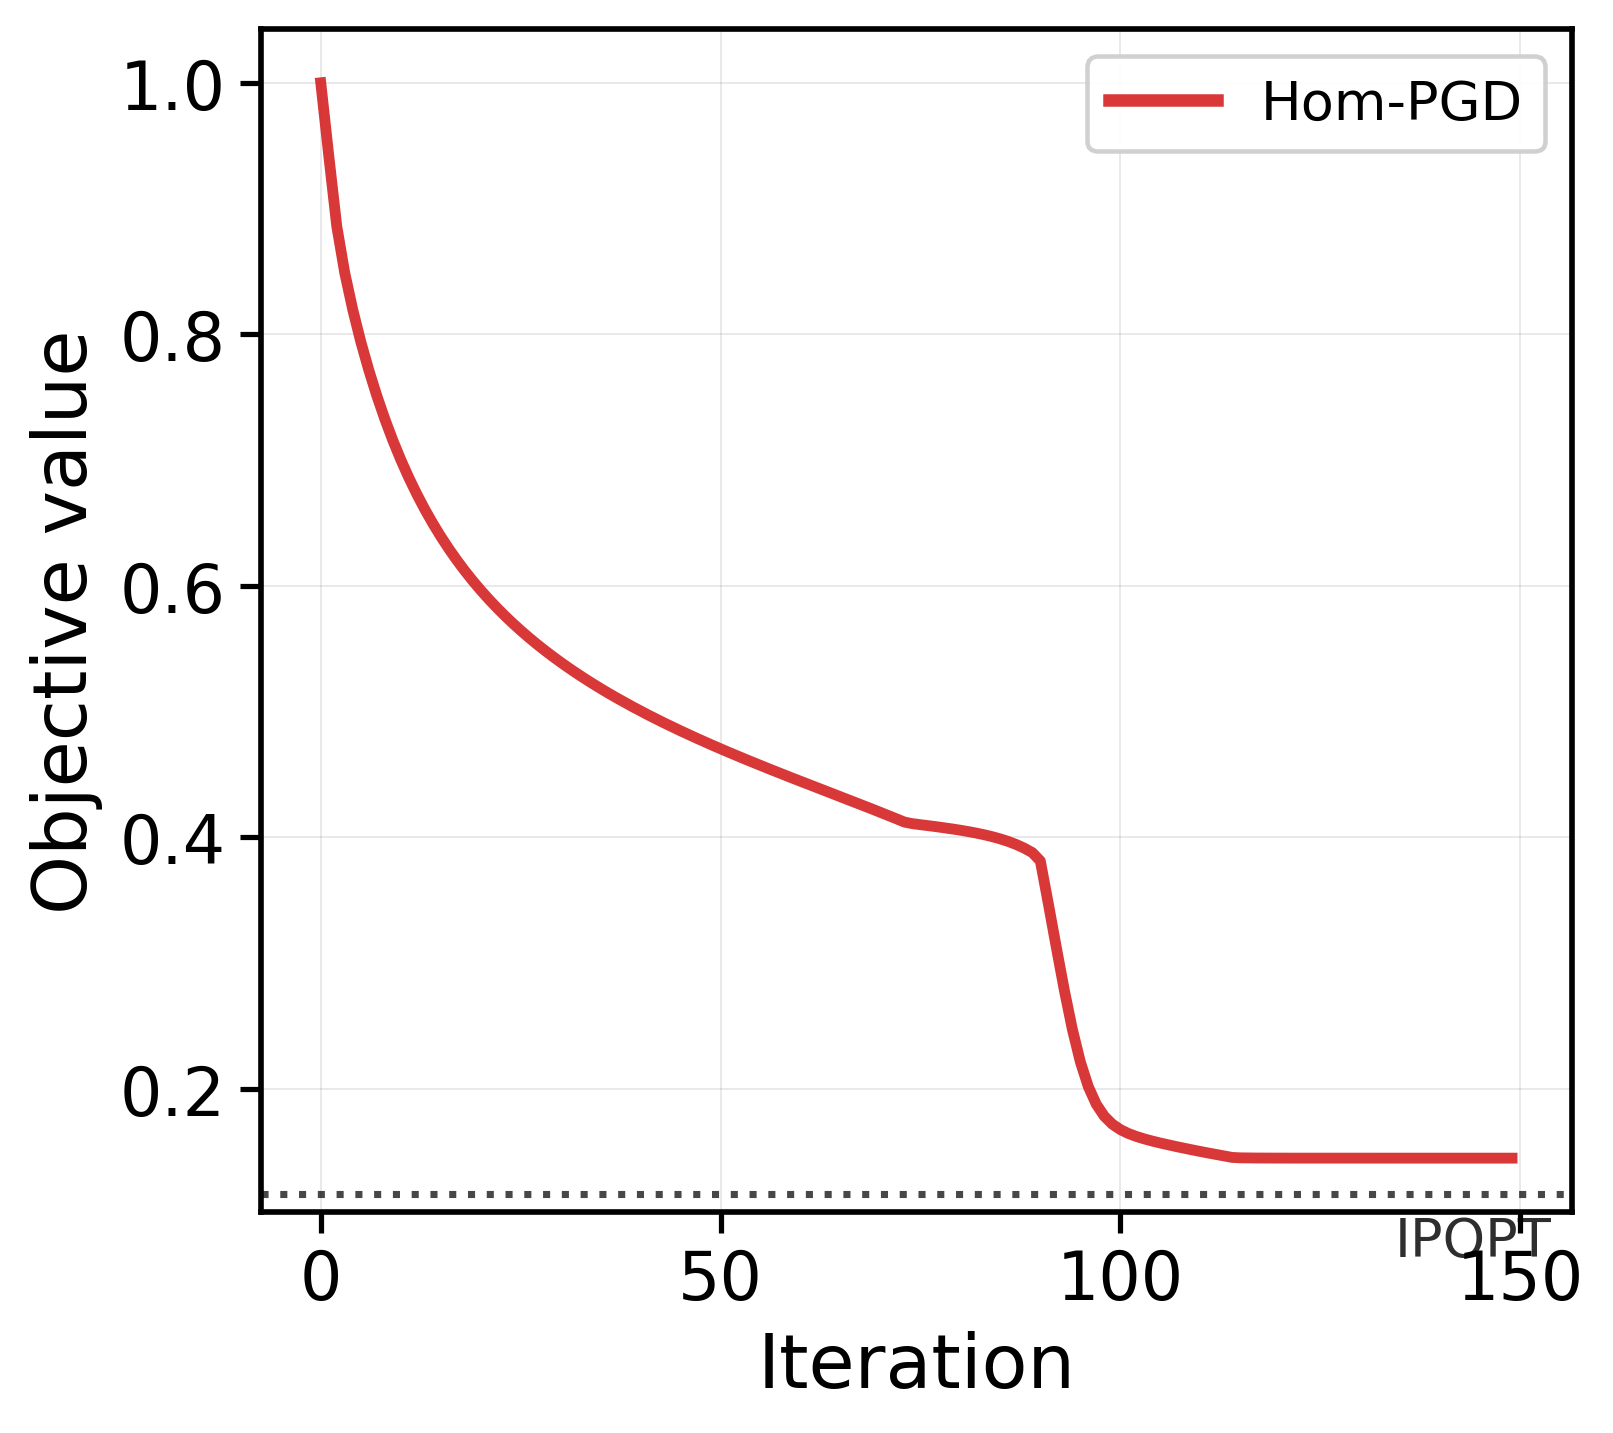

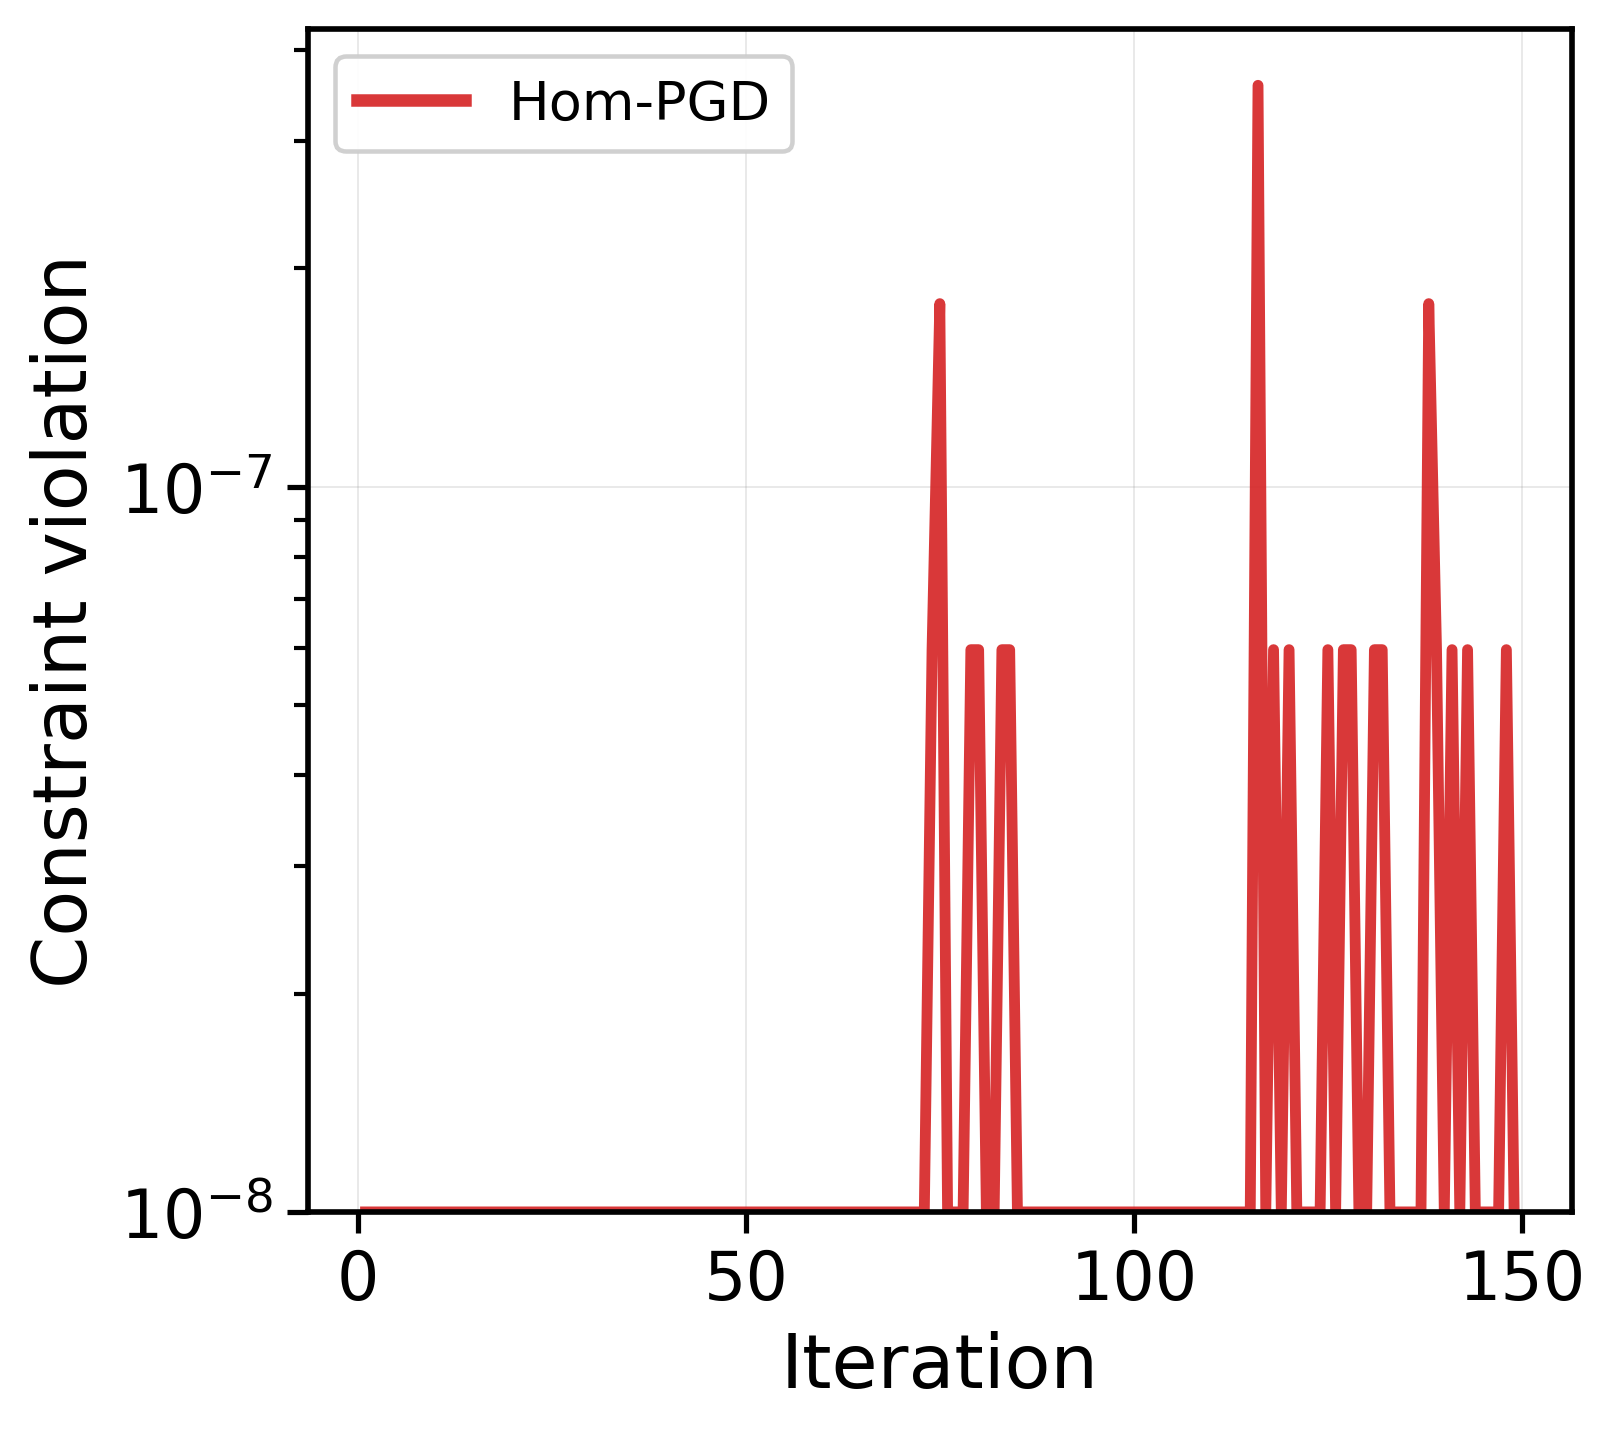

{'objective': {'iteration': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/objective_convergence_by_iter.pdf'),
  'iteration_logx': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/objective_convergence_by_iter_logx.pdf'),
  'time': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/objective_convergence_by_time.pdf'),
  'time_logx': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/objective_convergence_by_time_logx.pdf')},
 'violation': {'iteration': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/violation_convergence_by_iter.pdf'),
  'iteration_logx': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/02_star_hom_pgd_trajectory/violation_convergence_by_iter_logx.pdf'),
  'time': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tuto

In [4]:
from homopt.viz.convergence import draw_metric_convergence

method_labels = {'Hom-PGD': 'Hom-PGD'}
objective_paths = draw_metric_convergence(
    traces,
    'objective',
    'Objective value',
    TUTORIAL_CONFIG['figure_dir'] / 'objective_convergence.pdf',
    reference_value=float(reference['objective']),
    reference_label=reference['label'],
    method_labels=method_labels,
    show_variants=('iteration',),
)
violation_paths = draw_metric_convergence(
    traces,
    'full_violation',
    'Constraint violation',
    TUTORIAL_CONFIG['figure_dir'] / 'violation_convergence.pdf',
    log_y=True,
    y_min_clip=TUTORIAL_CONFIG['common_config']['convergence_threshold'],
    method_labels=method_labels,
    show_variants=('iteration',),
)
{'objective': objective_paths, 'violation': violation_paths}


## Takeaway

Hom-PGD performs its update in the latent unit ball and maps every latent iterate back to the star domain. The visualizations, curves, and PDF artifacts all originate from one shared benchmark record, so they remain aligned with the stated configuration.